# Task 2 — Step 6: Controlled Design Study — DAN alignment strength

**Chosen study:** $\lambda_{\text{MMD}}\in\{0.1,\,1,\,10\}$ for DAN. Everything else is fixed: splits, seed 6304, initialisation, source/target sampling, augmentation, BN policy, AdamW(1e-4, 1e-4), ≤ 30 epochs with patience 5 (manual budget), source-F1 early stopping, and the MMD kernel construction. $\lambda=1$ reuses the main DAN checkpoint (notebook 2), which was trained with the identical code path.

**Expectations, stated before looking at any result.**
| | λ = 0.1 | λ = 1 | λ = 10 |
|---|---|---|---|
| Source-val F1 | ≈ Source-only | small or no drop | likely drop: MMD competes with CE |
| MMD² at convergence | highest | lower | lowest |
| Domain separability | highest | lower | lowest |
| Sketch accuracy | small gain over Source-only | larger gain | uncertain: can fall if alignment mixes classes (Zhao et al., 2019) |

The target results below are for analysis only and are not used to change the tested settings. The last section asks which λ could have been picked **without** Sketch labels.

In [1]:
%matplotlib inline
import os, sys, json
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.insert(0, ROOT)

import torch, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

from shared.src.seed import set_seed, SEED
from shared.src.pacs_data import get_pacs_dataloaders, PACS_SOURCE_DOMAINS, PACS_CLASSES
from shared.src.plotting import use_style, SEQ_CMAP, PALETTE, NEUTRAL, INK_2, color_of, save_show
from task2_domain_adaptation.src.backbone import ResNet18Backbone
from shared.src.pacs_protocol import MAX_EPOCHS, PATIENCE
from task2_domain_adaptation.src.train import train_dan
from task2_domain_adaptation.src.evaluate import collect_outputs, domain_separability_from_features

use_style()
set_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DATA = os.path.join(ROOT, 'data', 'PACS')
SPLIT = os.path.join(ROOT, 'shared', 'splits', 'pacs_sketch_seed6304.json')
CKPT = os.path.join(ROOT, 'task2_domain_adaptation', 'checkpoints')
RES = os.path.join(ROOT, 'task2_domain_adaptation', 'results')
src_train, src_val, tgt_train, tgt_eval = get_pacs_dataloaders(DATA, SPLIT, source_batch_size=8, target_batch_size=24, eval_batch_size=64)
LAMBDAS = [0.1, 1.0, 10.0]
LAM_COL = {0.1: PALETTE[3], 1.0: PALETTE[0], 10.0: PALETTE[6]}
def paths(lam):
    tag = 'dan' if lam == 1.0 else f'dan_lambda{lam:g}'
    return os.path.join(CKPT, f'{tag}.pth'), os.path.join(CKPT, f'{tag}_history.json')

## 1. Train the two additional settings

In [2]:
FORCE_TRAIN = True
for lam in LAMBDAS:
    ck, hp = paths(lam)
    if lam == 1.0:
        assert os.path.exists(ck), 'run notebook 2 first'; continue
    if FORCE_TRAIN or not os.path.exists(ck):
        set_seed(SEED)
        out = train_dan(ResNet18Backbone(num_classes=7), src_train, tgt_train, src_val, device, lambda_mmd=lam,
                        max_epochs=MAX_EPOCHS, patience=PATIENCE, lr=1e-4, wd=1e-4, save_path=ck)
        json.dump({'config': dict(method='dan', lambda_mmd=lam, lr=1e-4, wd=1e-4, max_epochs=MAX_EPOCHS, patience=PATIENCE, seed=SEED),
                   'history': out['history'], 'best_epoch': out['best_epoch'], 'best_f1': out['best_f1']}, open(hp, 'w'), indent=1)
hists = {lam: json.load(open(paths(lam)[1])) for lam in LAMBDAS}
print({lam: (h['best_epoch'], round(h['best_f1'], 4)) for lam, h in hists.items()})

[dan] ep  1 | cls 0.463 | mmd 0.149 | |f_s| 45.9 |f_t| 42.1 | tgt max-class 0.25 | val F1 0.8796 *
[dan] ep  2 | cls 0.201 | mmd 0.075 | |f_s| 47.9 |f_t| 45.5 | tgt max-class 0.23 | val F1 0.9101 *
[dan] ep  3 | cls 0.173 | mmd 0.058 | |f_s| 47.8 |f_t| 46.8 | tgt max-class 0.23 | val F1 0.9239 *
[dan] ep  4 | cls 0.101 | mmd 0.054 | |f_s| 51.6 |f_t| 50.6 | tgt max-class 0.21 | val F1 0.9282 *
[dan] ep  5 | cls 0.100 | mmd 0.042 | |f_s| 50.5 |f_t| 49.2 | tgt max-class 0.22 | val F1 0.9328 *
[dan] ep  6 | cls 0.069 | mmd 0.039 | |f_s| 52.2 |f_t| 50.9 | tgt max-class 0.20 | val F1 0.9392 *
[dan] ep  7 | cls 0.051 | mmd 0.037 | |f_s| 53.0 |f_t| 52.4 | tgt max-class 0.20 | val F1 0.9341
[dan] ep  8 | cls 0.064 | mmd 0.039 | |f_s| 49.1 |f_t| 48.3 | tgt max-class 0.20 | val F1 0.8999
[dan] ep  9 | cls 0.064 | mmd 0.039 | |f_s| 50.1 |f_t| 48.9 | tgt max-class 0.20 | val F1 0.9338
[dan] ep 10 | cls 0.033 | mmd 0.030 | |f_s| 53.7 |f_t| 53.2 | tgt max-class 0.19 | val F1 0.9378
[dan] ep 11 | cls 

## 2. Training curves across λ

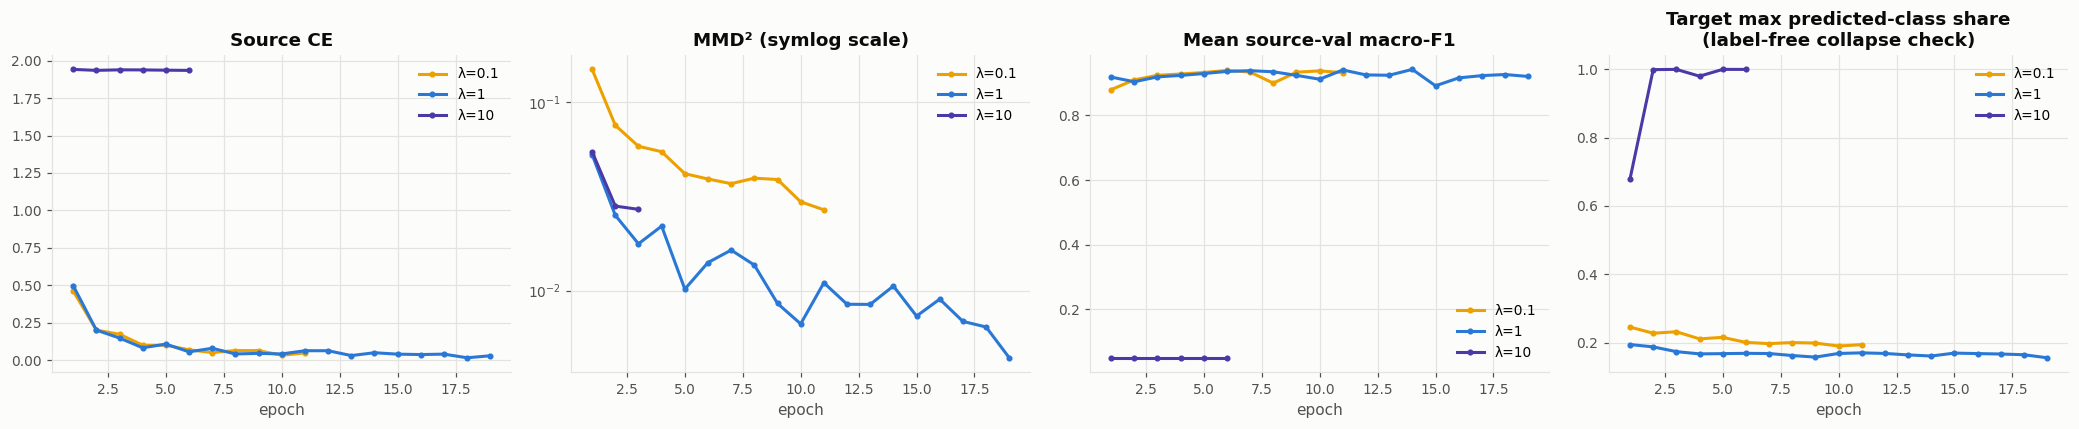

In [3]:
fig, ax = plt.subplots(1, 4, figsize=(19, 4))
for lam in LAMBDAS:
    H = hists[lam]['history']; e = np.arange(1, len(H['cls_loss']) + 1); c = LAM_COL[lam]
    ax[0].plot(e, H['cls_loss'], 'o-', ms=3, color=c, label=f'λ={lam:g}')
    ax[1].plot(e, H['align_loss'], 'o-', ms=3, color=c, label=f'λ={lam:g}')
    ax[2].plot(e, H['val_mean_f1'], 'o-', ms=3, color=c, label=f'λ={lam:g}')
    ax[3].plot(e, H['tgt_max_class_share'], 'o-', ms=3, color=c, label=f'λ={lam:g}')
ax[1].set_yscale('symlog', linthresh=1e-3)   # unbiased MMD² can dip slightly below 0
for a, t in zip(ax, ['Source CE', 'MMD² (symlog scale)', 'Mean source-val macro-F1', 'Target max predicted-class share\n(label-free collapse check)']):
    a.set_title(t); a.set_xlabel('epoch'); a.legend()
fig.tight_layout(); save_show(fig, os.path.join(RES, 'task2_controlled_training_curves.png'))

## 3. Evaluation (after all three settings are fixed)

In [4]:
rows, per_class = [], {}
so = pd.read_csv(os.path.join(RES, 'task2_main_table.csv'), index_col=0).loc['Source-only']
for lam in LAMBDAS:
    m = ResNet18Backbone(num_classes=7).to(device)
    m.load_state_dict(torch.load(paths(lam)[0], map_location=device, weights_only=True))
    o = {d: collect_outputs(m, src_val[d], device) for d in PACS_SOURCE_DOMAINS}; t = collect_outputs(m, tgt_eval, device)
    r = {'λ_MMD': lam}
    for d in PACS_SOURCE_DOMAINS:
        r[f'{d} F1'] = 100 * f1_score(o[d][2], o[d][0].argmax(1), average='macro')
    r['mean src acc'] = np.mean([100 * (o[d][0].argmax(1) == o[d][2]).mean() for d in PACS_SOURCE_DOMAINS])
    r['mean src F1'] = np.mean([r[f'{d} F1'] for d in PACS_SOURCE_DOMAINS])
    r['final MMD² (train)'] = hists[lam]['history']['align_loss'][hists[lam]['best_epoch'] - 1]
    r['domain separability'] = 100 * domain_separability_from_features(np.concatenate([o[d][1] for d in PACS_SOURCE_DOMAINS]), t[1], SEED)['domain_separability']
    r['Sketch acc'] = 100 * (t[0].argmax(1) == t[2]).mean(); r['Sketch F1'] = 100 * f1_score(t[2], t[0].argmax(1), average='macro')
    r['Δ Sketch acc vs SO'] = r['Sketch acc'] - so['Sketch acc']
    rows.append(r)
    per_class[f'λ={lam:g}'] = [100 * (t[0].argmax(1)[t[2] == c] == c).mean() for c in range(7)]
study = pd.DataFrame(rows).set_index('λ_MMD')
study.to_csv(os.path.join(RES, 'task2_controlled_study.csv'))
study.round(3)

,photo F1,art_painting F1,cartoon F1,mean src acc,mean src F1,final MMD² (train),domain separability,Sketch acc,Sketch F1,Δ Sketch acc vs SO
λ_MMD,,,,,,,,,,
0.1,96.517,90.490,94.747,93.831,93.918,0.039,96.566,70.552,69.690,11.326
1.0,96.985,91.288,94.448,94.185,94.241,0.011,81.456,65.487,60.952,6.261
10.0,5.850,5.143,4.208,21.657,5.067,0.054,85.302,4.072,1.118,-55.154


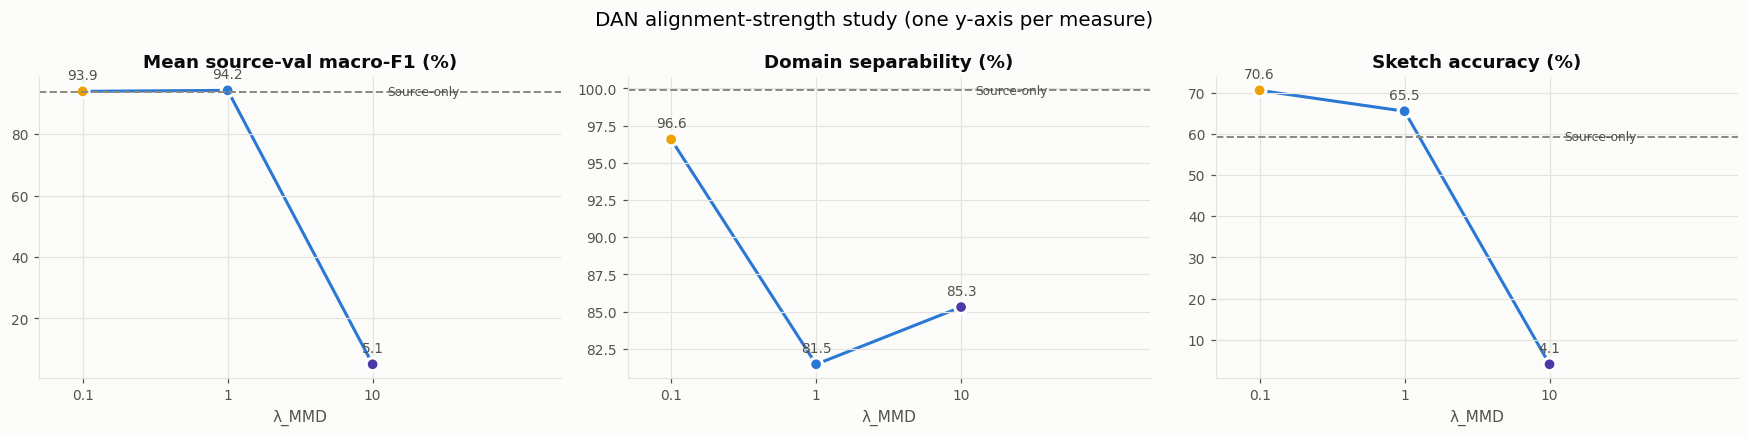

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(16, 4))
xs = np.arange(len(LAMBDAS)); labels = [f'{l:g}' for l in LAMBDAS]
panels = [('mean src F1', 'Mean source-val macro-F1 (%)', so['mean src F1']),
          ('domain separability', 'Domain separability (%)', so['domain separability']),
          ('Sketch acc', 'Sketch accuracy (%)', so['Sketch acc'])]
for a, (col, title, ref) in zip(ax, panels):
    a.plot(xs, study[col], '-', color=color_of('DAN'), zorder=1)
    a.scatter(xs, study[col], s=70, color=[LAM_COL[l] for l in LAMBDAS], edgecolor='white', linewidth=2, zorder=2)
    for x_, v in zip(xs, study[col]): a.annotate(f'{v:.1f}', (x_, v), xytext=(0, 8), textcoords='offset points', ha='center', fontsize=9, color=INK_2)
    a.axhline(ref, color=NEUTRAL, ls='--', lw=1.3); a.text(xs[-1] + 0.1, ref, 'Source-only', fontsize=8, color=INK_2, va='center')
    a.set_xticks(xs); a.set_xticklabels(labels); a.set_xlabel('λ_MMD'); a.set_title(title); a.set_xlim(-0.3, len(LAMBDAS) - 0.3 + 0.6)
fig.suptitle('DAN alignment-strength study (one y-axis per measure)', fontsize=13); fig.tight_layout()
save_show(fig, os.path.join(RES, 'task2_controlled_tradeoff.png'))

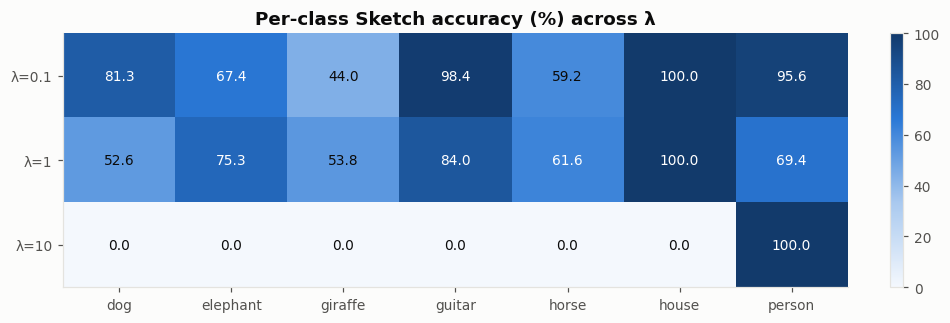

In [6]:
pcd = pd.DataFrame(per_class, index=PACS_CLASSES)
fig, a = plt.subplots(figsize=(10, 3))
im = a.imshow(pcd.T.values, cmap=SEQ_CMAP, vmin=0, vmax=100, aspect='auto')
for i in range(pcd.shape[1]):
    for j in range(7):
        v = pcd.T.values[i, j]; a.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=9, color='white' if v > 60 else '#0b0b0b')
a.set_xticks(range(7)); a.set_xticklabels(PACS_CLASSES); a.set_yticks(range(pcd.shape[1])); a.set_yticklabels(pcd.columns); a.grid(False)
a.set_title('Per-class Sketch accuracy (%) across λ'); fig.colorbar(im, ax=a, fraction=0.03)
save_show(fig, os.path.join(RES, 'task2_controlled_per_class.png'))

## 4. What could have been selected without Sketch labels?
Only source-side and label-free quantities are available at selection time: source-validation F1, the MMD² level, and the target *prediction* histogram. The cell lists them next to the (analysis-only) Sketch accuracy.

In [7]:
sel = study[['mean src F1', 'final MMD² (train)', 'domain separability']].copy()
sel['target max-class share @ selected epoch'] = [hists[l]['history']['tgt_max_class_share'][hists[l]['best_epoch'] - 1] for l in LAMBDAS]
sel['(analysis only) Sketch acc'] = study['Sketch acc']
print('λ with the best source-val F1 (a label-free rule):', study['mean src F1'].idxmax())
sel.round(3)

λ with the best source-val F1 (a label-free rule): 1.0


,mean src F1,final MMD² (train),domain separability,target max-class share @ selected epoch,(analysis only) Sketch acc
λ_MMD,,,,,
0.1,93.918,0.039,96.566,0.200,70.552
1.0,94.241,0.011,81.456,0.160,65.487
10.0,5.067,0.054,85.302,0.679,4.072
